# Reproducibility: All Paper Figures

This notebook reproduces every figure and table from:

> Kalmykov et al., *DCT Basis Benchmarks for Neural Image Compression*.

## Parameter Reference

| Figure | Script / source | DCT size | Codec settings |
|--------|----------------|----------|----------------|
| Fig. 1 | `02_paper_figures.ipynb` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2a | `02_paper_figures.ipynb` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2b | `02_paper_figures.ipynb` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2c | `scripts/run_finetune.py --size 128` | 128 | fine-tuned `cheng2020-anchor`, q=6 |
| Fig. 3 | `plot_fig3_dct_grid.py` | **256** | q=1 (low) and q=6 (high); TCM: p=64/128; JPEG/WebP: q=20/95; JXL: d=4.0/0.6 |
| Fig. 4a | `02_paper_figures.ipynb` | 64–1024 | `cheng2020-anchor/attn`, q=1–6 |
| Fig. 4b | `plot_fig4b_artifact.py` | **1024** | `cheng2020-anchor`, q=6 (artifact) |
| Fig. 5 | `plot_leakage_vs_bpp.py` | **256** | all q levels (rate sweep) |
| Fig. S1 | `run_directional.py` | **512** | matched ≈2.5 bpp; JPEG q=43, WebP q=70, JXL d=2.5 |
| Fig. S2 | `plot_distortion_consistency_paper.py` | 512 | `cheng2020-anchor`, q=6; Gaussian noise σ∈[0.01,0.2] |
| Fig. S3 | `run_finetune.py` | **1024** | `cheng2020-anchor`, q=6, 900 steps |
| Table I | `run_kodak_eval.py` | **512** | all codecs, highest quality, 24 Kodak images |

Outputs are saved to `paper/figures/`.

In [9]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import torch
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import IFrame

from dct_nic import evaluate_codec, load_model

%config InlineBackend.figure_format = "retina"

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS = Path('../results')
OUT = Path('../paper/figures')
OUT.mkdir(parents=True, exist_ok=True)

# Paper-style matplotlib (matches 01_demo)
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8.5,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 7.2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.7,
    "lines.linewidth": 1.3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


def style_axis(ax, grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid:
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.35)
    ax.tick_params(direction="out")


def add_band_background(ax, size, low_c, mid_c, high_c, alpha=0.42):
    b1, b2 = size // 3, 2 * size // 3
    ax.axvspan(0, b1, color=low_c, alpha=alpha, zorder=0)
    ax.axvspan(b1, b2, color=mid_c, alpha=alpha, zorder=0)
    ax.axvspan(b2, size, color=high_c, alpha=alpha, zorder=0)

# Shared style constants (IEEE SPL)

COLORS = {
    'cheng2020-anchor': '#7E489E', 'cheng2020-attn': '#E883B6',
    'mbt2018-mean': '#717171', 'mbt2018': '#A0BBD4',
    'bmshj2018-hyperprior': '#B8B028', 'bmshj2018-factorized': '#7B4B3D',
    'ftic': '#D82F30', 'tcm': '#F0801F',
    'jpeg': '#287BB8', 'webp': '#429A38', 'jpegxl': '#3AC1CF',
}
MARKERS = {
    'cheng2020-anchor': 's', 'cheng2020-attn': 'D',
    'mbt2018-mean': 'o', 'mbt2018': 'P',
    'bmshj2018-hyperprior': 'p', 'bmshj2018-factorized': '^',
    'ftic': 'h', 'tcm': 'X',
    'jpeg': '*', 'webp': 'v', 'jpegxl': 'd',
}
LABELS = {
    'cheng2020-anchor': 'Cheng2020-Anchor', 'cheng2020-attn': 'Cheng2020-Attention',
    'mbt2018-mean': 'MBT2018-Mean', 'mbt2018': 'MBT2018',
    'bmshj2018-hyperprior': 'BMSHJ2018-Hyperprior', 'bmshj2018-factorized': 'BMSHJ2018-Factorized',
    'ftic': 'FTIC', 'tcm': 'TCM',
    'jpeg': 'JPEG', 'webp': 'WebP', 'jpegxl': 'JPEG XL',
}
TRADITIONAL = {'jpeg', 'webp', 'jpegxl'}

print(f'Device: {DEVICE}  |  Output: {OUT}')

Device: cuda  |  Output: ../paper/figures


---
## Fig. 1 - DCT Basis, Frequency Map, and Codec Reconstruction

**Settings:** `cheng2020-anchor`, q=6, size=**128×128**

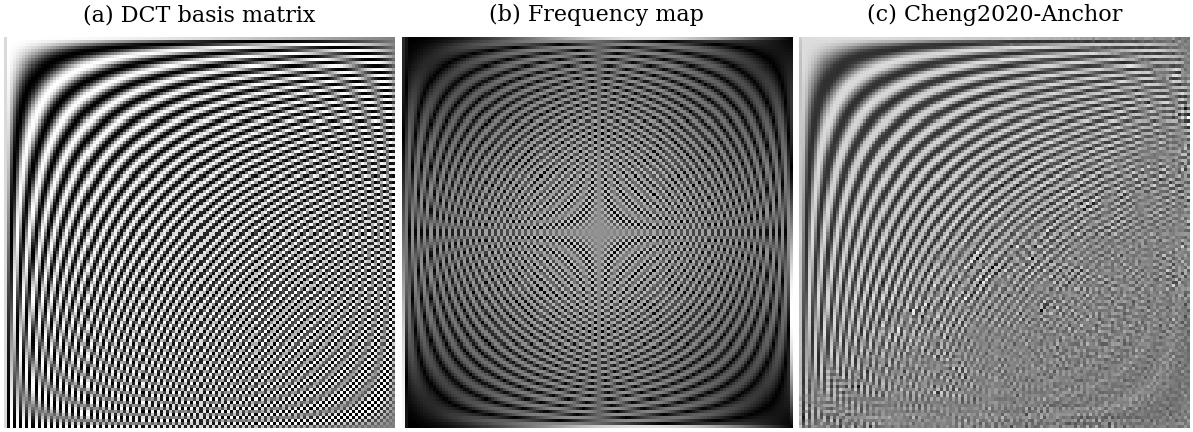

Fig. 1 saved.


In [10]:
# Parameters for Fig. 1
SIZE_FIG1 = 128
MODEL_FIG1 = 'cheng2020-anchor'
Q_FIG1 = 6

model = load_model(MODEL_FIG1, Q_FIG1, DEVICE)
result = evaluate_codec(model, size=SIZE_FIG1, device=DEVICE, model_name=MODEL_FIG1, num_runs=1)

orig = result['orig']   # (128, 128, 3)
recon = result['recon'] # (128, 128, 3)
recon_disp = np.clip((recon - recon.min()) / (recon.max() - recon.min() + 1e-9), 0, 1)

# Diagonal-direction frequency map (gradient magnitude of DCT basis)
from dct_nic import build_dct_basis
D_raw = build_dct_basis(SIZE_FIG1)
gy, gx = np.gradient(D_raw)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(6, 2.2))
axes[0].imshow(orig.mean(axis=2), cmap='gray'); axes[0].axis('off')
axes[0].set_title('(a) DCT basis matrix', fontsize=8)
axes[1].imshow(freq_map, cmap='gray'); axes[1].axis('off')
axes[1].set_title('(b) Frequency map', fontsize=8)
axes[2].imshow(recon_disp.mean(axis=2), cmap='gray'); axes[2].axis('off')
axes[2].set_title('(c) Cheng2020-Anchor', fontsize=8)
plt.tight_layout(pad=0.3)
plt.savefig(OUT / 'fig1.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Fig. 1 saved.')

---
## Fig. 2 - Frequency-Response Matrix, Metrics, and Fine-Tuning

**Settings:** `cheng2020-anchor`, q=6, size=**128×128**

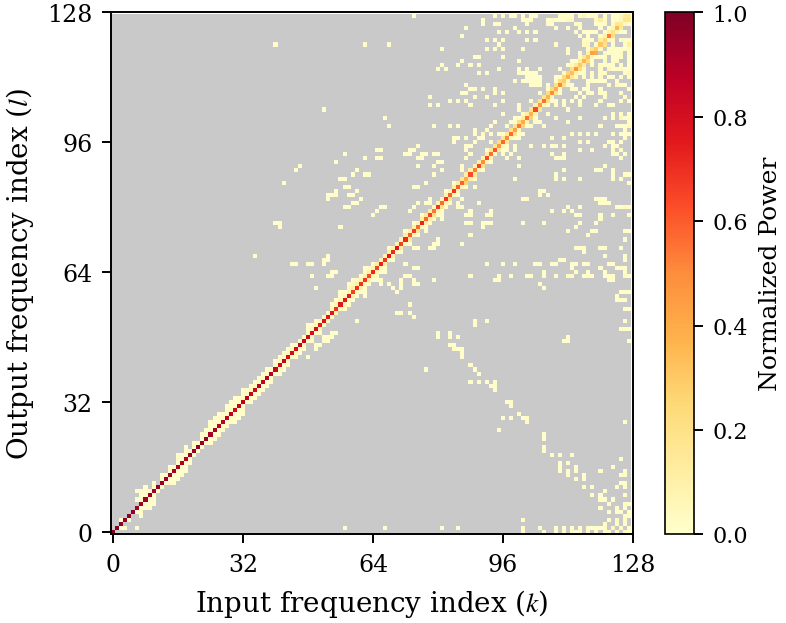

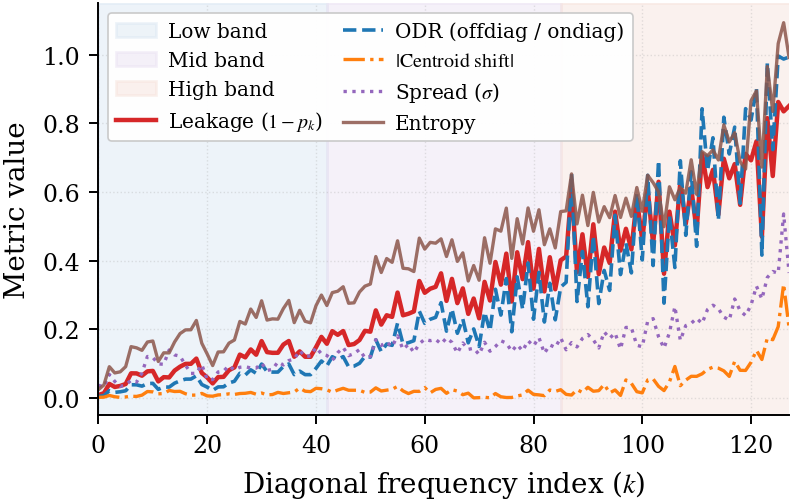

Fig. 2a, 2b saved. Run scripts/run_finetune.py --size 128 for Fig. 2c.


In [11]:
R = result['R']
k = np.arange(SIZE_FIG1)
low_c, mid_c, high_c = "#D9E6F2", "#E9E0F2", "#F6E1DA"

# Fig. 2a: Response matrix
fig_a, ax_a = plt.subplots(figsize=(4.0, 4.0))
threshold = 0.005
R_masked = np.ma.masked_less(R, threshold)
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#C9C9C9")
im = ax_a.imshow(
    R_masked, origin="lower",
    cmap=cmap, vmin=0, vmax=1,
    interpolation="nearest", aspect="equal"
)
ax_a.set_xlim(-0.5, SIZE_FIG1 - 0.5)
ax_a.set_ylim(-0.5, SIZE_FIG1 - 0.5)
ax_a.set_xlabel(r"Input frequency index ($k$)")
ax_a.set_ylabel(r"Output frequency index ($l$)")
ticks = np.arange(0, SIZE_FIG1 + 1, 32)
ax_a.set_xticks(ticks)
ax_a.set_yticks(ticks)
ax_a.grid(False)
divider = make_axes_locatable(ax_a)
cax = divider.append_axes("right", size="5.5%", pad=0.16)
cb = fig_a.colorbar(im, cax=cax)
cb.set_label("Normalized Power", fontsize=9)
cb.ax.tick_params(labelsize=8)
cb.outline.set_linewidth(0.6)
fig_a.tight_layout(pad=0.3)
fig_a.savefig(OUT / 'fig2a_response_matrix.pdf', bbox_inches='tight')
plt.show()

# Fig. 2b: Metric curves
fig_b, ax_b = plt.subplots(figsize=(4.0, 2.6))
add_band_background(ax_b, SIZE_FIG1, low_c, mid_c, high_c, alpha=0.45)
line1, = ax_b.plot(k, result['leakage'], color="#D62728", lw=1.6, ls="-", label=r"Leakage ($1 - p_k$)")
line2, = ax_b.plot(k, result['odr'], color="#1F77B4", lw=1.3, ls="--", label=r"ODR (offdiag / ondiag)")
line3, = ax_b.plot(k, np.abs(result['centroid_shift']), color="#FF7F0E", lw=1.2, ls="-.", label=r"$|\mathrm{Centroid\ shift}|$")
line4, = ax_b.plot(k, result['spread'], color="#9467BD", lw=1.2, ls=":", label=r"Spread ($\sigma$)")
line5, = ax_b.plot(k, result['entropy'] / np.log(2), color="#8C564B", lw=1.2, ls="-", alpha=0.85, label="Entropy")
ax_b.set_xlim(0, SIZE_FIG1 - 1)
ax_b.set_ylim(-0.05, 1.15)
ax_b.set_xlabel(r"Diagonal frequency index ($k$)")
ax_b.set_ylabel("Metric value")
style_axis(ax_b, grid=True)
band_patches = [
    mpatches.Patch(color=low_c, alpha=0.45, label="Low band"),
    mpatches.Patch(color=mid_c, alpha=0.45, label="Mid band"),
    mpatches.Patch(color=high_c, alpha=0.45, label="High band"),
]
leg_b = ax_b.legend(handles=band_patches + [line1, line2, line3, line4, line5], loc="upper left", ncol=2,
                   frameon=True, fancybox=True, framealpha=0.96, edgecolor="#C8C8C8", borderpad=0.4,
                   columnspacing=1.0, handlelength=2.0, handletextpad=0.6)
leg_b.get_frame().set_linewidth(0.6)
fig_b.tight_layout(pad=0.3)
fig_b.savefig(OUT / 'fig2b_metrics.pdf', bbox_inches='tight')
plt.show()

print('Fig. 2a, 2b saved. Run scripts/run_finetune.py --size 128 for Fig. 2c.')

---
## Fig. 3 - DCT-Basis Response Grid (All Codecs)

**Settings:** size=**256×256**, low quality (q=1 / native low) and high quality (q=6 / native high)

> This figure requires pre-computed reconstructed images in `results/`.

In [7]:
# Load pre-computed metrics for annotation
csv_256 = RESULTS / 'leakage_vs_bpp' / 'scan_leakage_vs_bpp_256.csv'
if not csv_256.exists():
    print('Run: python scripts/run_benchmark.py --size 256 --quality-sweep')
else:
    df256 = pd.read_csv(csv_256)
    print('Available models:', df256['model'].unique().tolist())

# Pre-built figure from paper:
prebuilt = Path('../paper/figures/fig3_dct_response_grid.pdf')
if prebuilt.exists():
    print(f'\nPre-built figure available: {prebuilt}')
    display(IFrame(str(prebuilt), width=900, height=300))

Available models: ['ftic', 'tcm', 'cheng2020-anchor', 'cheng2020-attn', 'bmshj2018-factorized', 'bmshj2018-hyperprior', 'mbt2018-mean', 'mbt2018', 'webp', 'jpegxl', 'jpeg']

Pre-built figure available: ../paper/figures/fig3_dct_response_grid.pdf


---
## Fig. 4 - Median Leakage vs Quality (Cheng2020 family, multiple sizes)

**Settings:** `cheng2020-anchor`, `cheng2020-attn`, q=1–6, sizes={64,128,256,512,1024}

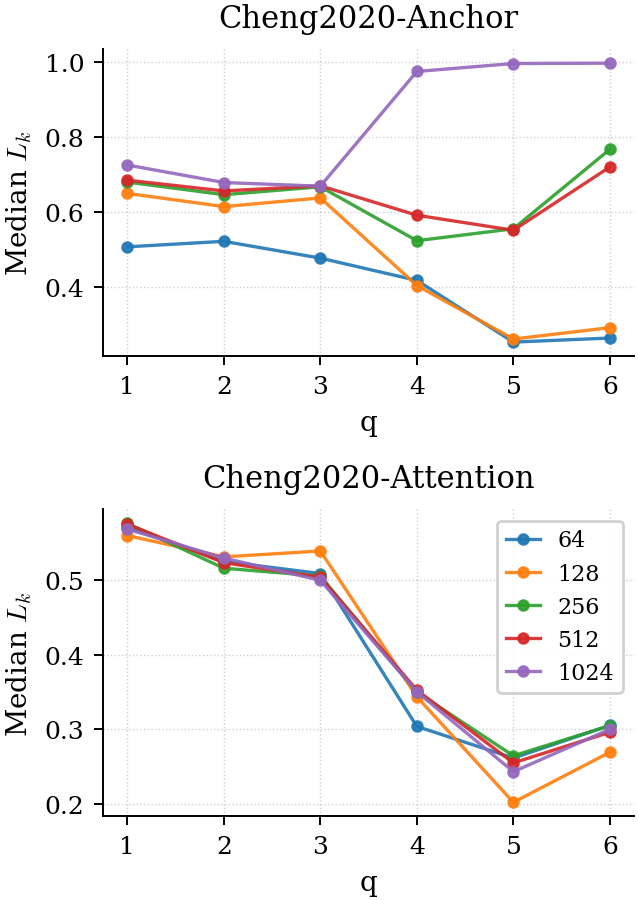

Fig. 4a saved.


In [6]:
df_all = pd.read_csv(RESULTS / "all_metrics_summary.csv")

# IEEE SPL single column: 3.3" width
plt.rcParams.update({
    "font.size": 9,
    "mathtext.fontset": "cm",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

models = [("Cheng2020-Anchor", "cheng2020-anchor"), ("Cheng2020-Attention", "cheng2020-attn")]
sizes = ["64x64", "128x128", "256x256", "512x512", "1024x1024"]
size_labels = ["64", "128", "256", "512", "1024"]

fig, axes = plt.subplots(2, 1, figsize=(3.3, 4.6))

for i, (title, model_id) in enumerate(models):
    ax = axes[i]
    sub = df_all[df_all["Model"] == model_id]
    for sz, lbl in zip(sizes, size_labels):
        s = sub[sub["Size"] == sz].sort_values("q")
        if not s.empty:
            ax.plot(s["q"], s["L_k"], marker="o", markersize=3.5, linewidth=1.2, alpha=0.9, label=lbl)
    ax.set_title(title, pad=8)
    ax.set_ylabel(r"Median $L_k$")
    ax.set_xlabel("q")
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].legend(loc="upper right", frameon=True, framealpha=0.9, edgecolor="0.8", fontsize=8, handlelength=1.5)

fig.tight_layout(pad=0.5)
fig.subplots_adjust(hspace=0.5)
fig.savefig(OUT / "fig4_leakage_vs_quality.pdf", bbox_inches="tight", pad_inches=0.03, dpi=300)
plt.show()
print("Fig. 4a saved.")

---
## Fig. 5 - Rate-Leakage Comparison at 256×256

**Settings:** all codecs, full quality sweep, size=**256×256**

> Data: `results/leakage_vs_bpp/scan_leakage_vs_bpp_256.csv`  
> Generate: `python scripts/run_benchmark.py --size 256 --quality-sweep`

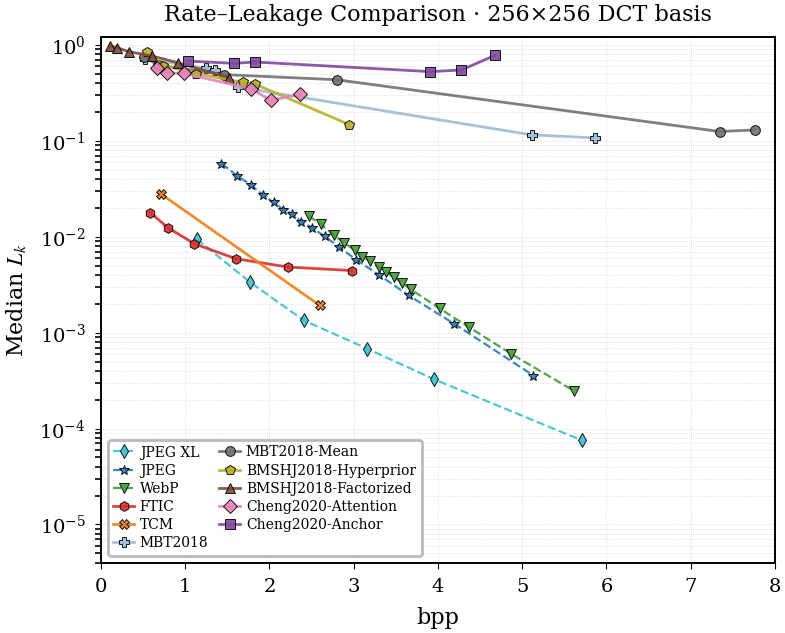

In [12]:
csv_path = RESULTS / "leakage_vs_bpp" / "scan_leakage_vs_bpp_256.csv"
df = pd.read_csv(csv_path).drop_duplicates(subset=["model", "bpp"])

MODEL_COLORS = {
    "cheng2020-anchor": "#7E489E",
    "cheng2020-attn": "#E883B6",
    "mbt2018-mean": "#717171",
    "mbt2018": "#A0BBD4",
    "bmshj2018-hyperprior": "#B8B028",
    "bmshj2018-factorized": "#7B4B3D",
    "ftic": "#D82F30",
    "tcm": "#F0801F",
    "jpeg": "#287BB8",
    "webp": "#429A38",
    "jpegxl": "#3AC1CF",
}

MODEL_MARKERS = {
    "cheng2020-anchor": "s",
    "cheng2020-attn": "D",
    "mbt2018-mean": "o",
    "mbt2018": "P",
    "bmshj2018-hyperprior": "p",
    "bmshj2018-factorized": "^",
    "ftic": "h",
    "tcm": "X",
    "jpeg": "*",
    "webp": "v",
    "jpegxl": "d",
}

LABEL_TEXT = {
    "bmshj2018-factorized": "BMSHJ2018-Factorized",
    "bmshj2018-hyperprior": "BMSHJ2018-Hyperprior",
    "mbt2018-mean": "MBT2018-Mean",
    "mbt2018": "MBT2018",
    "cheng2020-anchor": "Cheng2020-Anchor",
    "cheng2020-attn": "Cheng2020-Attention",
    "tcm": "TCM",
    "ftic": "FTIC",
    "jpeg": "JPEG",
    "jpegxl": "JPEG XL",
    "webp": "WebP",
}

LINESTYLES = {
    "jpeg": "--",
    "webp": "--",
    "jpegxl": "--",
}

PLOT_ORDER_ALL = [
    "jpegxl",
    "jpeg",
    "webp",
    "ftic",
    "tcm",
    "mbt2018",
    "mbt2018-mean",
    "bmshj2018-hyperprior",
    "bmshj2018-factorized",
    "cheng2020-attn",
    "cheng2020-anchor",
]

order = [m for m in PLOT_ORDER_ALL if m in df["model"].unique()]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

fig, ax = plt.subplots(figsize=(4.0, 3.2))

for name in order:
    sub = df[df["model"] == name].sort_values("bpp")
    if sub.empty:
        continue

    bpp = sub["bpp"].values
    lk = sub["L_k"].values

    color = MODEL_COLORS.get(name, "gray")
    marker = MODEL_MARKERS.get(name, "o")
    ls = LINESTYLES.get(name, "-")
    lw = 0.8 if ls == "--" else 1.0

    ax.plot(
        bpp,
        lk,
        ls,
        color=color,
        marker=marker,
        markersize=3.5,
        markeredgecolor="black",
        markeredgewidth=0.35,
        linewidth=lw,
        alpha=0.9,
        zorder=5,
        label=LABEL_TEXT.get(name, name),
    )

ax.set_yscale("log")
ax.set_xlabel("bpp", fontsize=8)
ax.set_ylabel(r"Median $L_k$", fontsize=8)
ax.tick_params(labelsize=7, length=2, width=0.4)
ax.grid(True, ls=":", lw=0.3, alpha=0.5, which="both")
ax.set_xlim(0.0, 8.0)
ax.set_ylim(4e-6, 1.2)

ax.set_title("Rate–Leakage Comparison · 256×256 DCT basis", fontsize=8)

ax.legend(
    fontsize=5,
    ncol=2,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    edgecolor="0.7",
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.3,
)

fig.tight_layout(pad=0.4)
plt.show()

---
## Fig. S1 — Directional Leakage Anisotropy

**Settings:** size=**512×512**, matched ≈2.5 bpp (JPEG q=43, WebP q=70, JXL d=2.5), angles: 0°–90°

> Generate: `python scripts/run_directional.py --size 512 --matched-bpp`

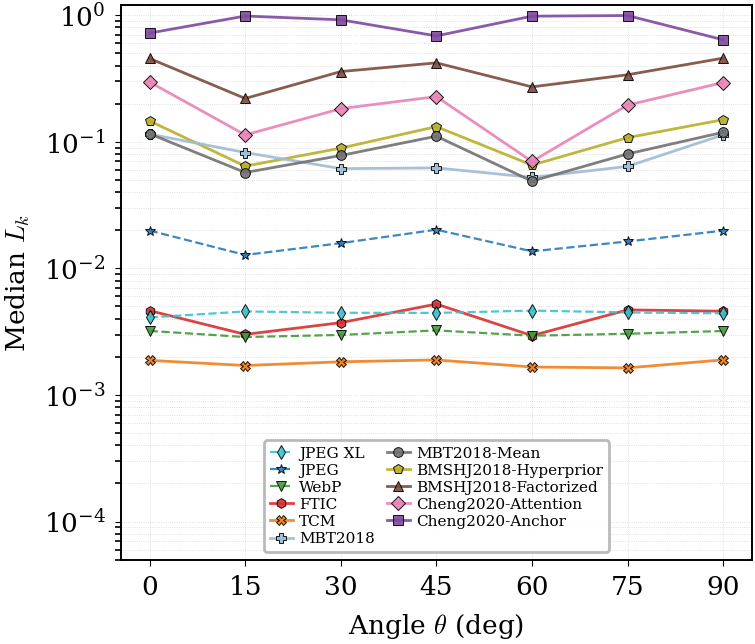

Fig. S1 saved.


In [2]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from scripts.plot_directional_paper import load_data, make_figure

_, pivot = load_data(size_filter=512, quality_filter=6)
if pivot.empty:
    print("Missing data. Run: python scripts/run_directional.py --matched-bpp")
else:
    fig = make_figure(pivot)
    fig.savefig(OUT / "figS1_directional_leakage.pdf", bbox_inches="tight", pad_inches=0.03, dpi=300)
    plt.show()
    print("Fig. S1 saved.")

---
## Fig. S3 — Fine-Tuning Result at 1024×1024

**Settings:** `cheng2020-anchor`, q=6, size=**1024×1024**, 900 steps, Adam lr=1e-4

> Generate: `python scripts/run_finetune.py --size 1024 --steps 900`

In [3]:
# Check if pre-built finetune figure exists
ft_pdf = OUT / 'finetune_cheng2020-anchor_1024_q6.pdf'
if ft_pdf.exists():
    print(f'Found: {ft_pdf}')
else:
    print('Run: python scripts/run_finetune.py --size 1024 --steps 900')
    print('For quick demo (128×128):')
    print('    python scripts/run_finetune.py --size 128 --steps 200')

Run: python scripts/run_finetune.py --size 1024 --steps 900
For quick demo (128×128):
    python scripts/run_finetune.py --size 128 --steps 200


---
## All Five Metrics: Band-wise Summary

Heatmap of all 5 metrics across all models, showing low / mid / high frequency bands.

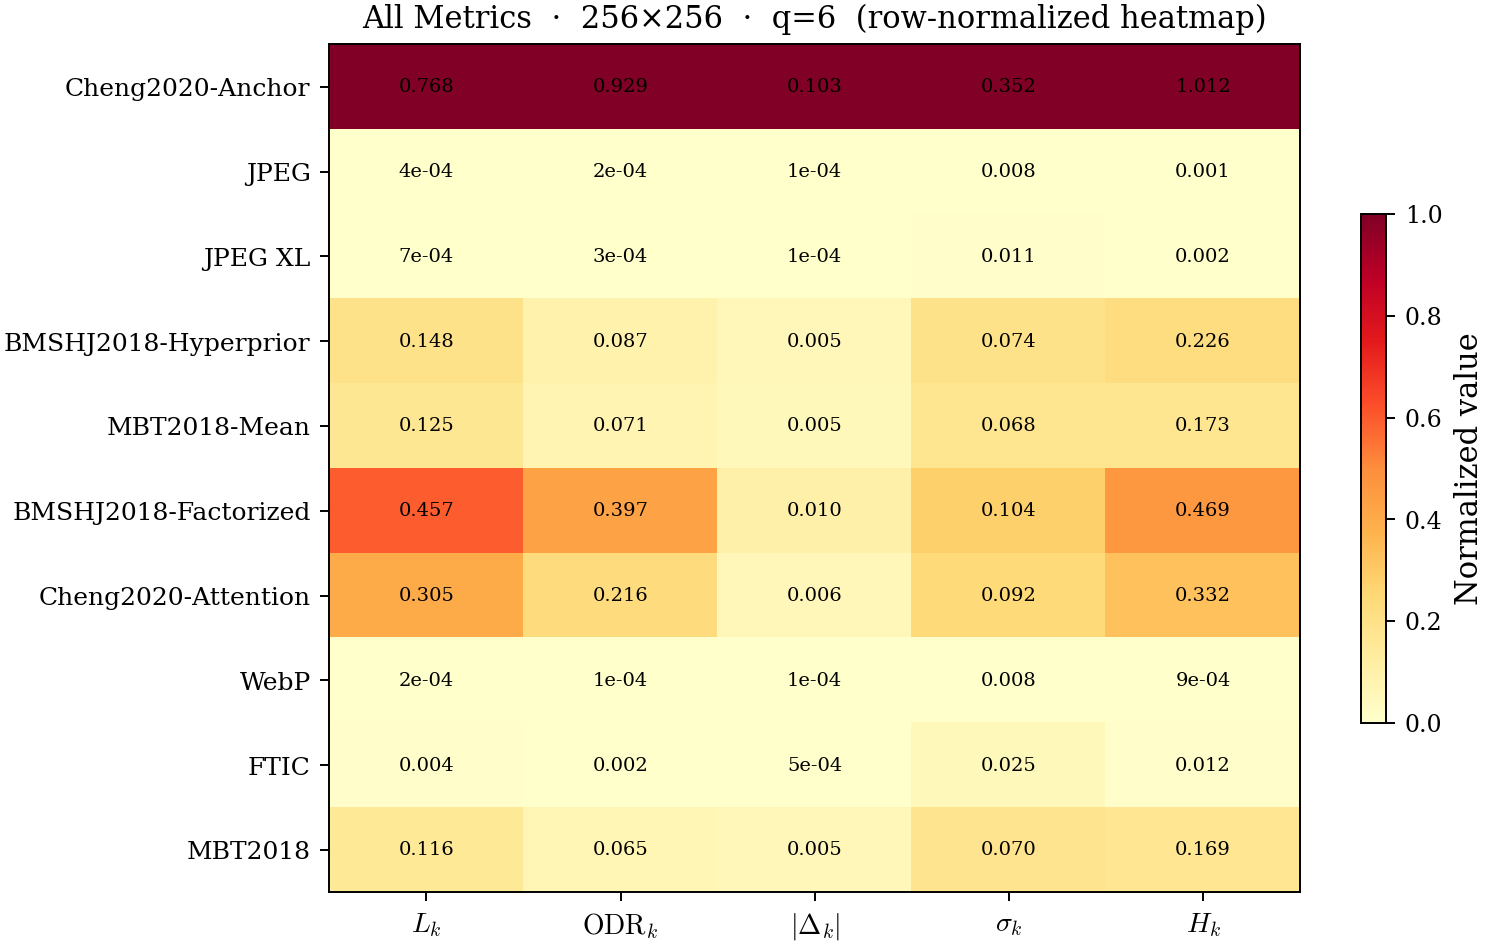

In [ ]:
df_all = pd.read_csv(RESULTS / 'all_metrics_summary.csv')
# Take q=6, size=256
df_q6 = df_all[(df_all.get('q', pd.Series(dtype=float)) == 6) & (df_all['Size'] == '256x256')]
if df_q6.empty:
    df_q6 = df_all[df_all['Size'] == '256x256'].sort_values('q', ascending=False).groupby('Model').first().reset_index()

METRIC_COLS = ['L_k', 'ODR_k', '|Delta_c_k|', 's_k', 'H_k_bits']
METRIC_LABELS = [r'$L_k$', r'$\mathrm{ODR}_k$', r'$|\Delta_k|$', r'$\sigma_k$', r'$H_k$']

avail_cols = [c for c in METRIC_COLS if c in df_q6.columns]
avail_labels = [METRIC_LABELS[METRIC_COLS.index(c)] for c in avail_cols]

if avail_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    mat = df_q6.set_index('Model')[avail_cols].values.astype(float)
    model_names = [LABELS.get(m, m) for m in df_q6['Model'].tolist()]
    # Normalize each column to [0,1] for comparison
    mat_norm = (mat - mat.min(axis=0)) / (mat.max(axis=0) - mat.min(axis=0) + 1e-12)
    im = ax.imshow(mat_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(avail_cols))); ax.set_xticklabels(avail_labels, fontsize=10)
    ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=9)
    for i in range(len(model_names)):
        for j in range(len(avail_cols)):
            v = mat[i, j]
            ax.text(j, i, f'{v:.3f}' if v >= 0.001 else f'{v:.0e}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.6, label='Normalized value')
    ax.set_title('All Metrics  ·  256×256  ·  q=6  (row-normalized heatmap)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / 'all_metrics_heatmap.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Metric columns not found. Run full benchmark first.')